# FedMamba-SALT: Centralized Pre-training Experiment

**Self-supervised knowledge distillation from a frozen MAE ViT-B/16 teacher to a lightweight Inception-Mamba student encoder using asymmetric augmentation (SALT).**

This notebook runs the end-to-end centralized baseline experiment on Google Colab Pro — from environment setup through final evaluation — producing a fully trained encoder ready for downstream classification or federated deployment.

### Pipeline

| # | Stage | Description |
|---|-------|-------------|
| 1 | **Environment Setup** | Mount Drive, install Mamba CUDA kernels, patch `timm` for PyTorch 2.x |
| 2 | **Checkpoint Verification** | Validate MAE ViT-B/16 weight format and prefix stripping |
| 3 | **Smoke Tests** | Run loss, teacher, and end-to-end component tests before committing GPU hours |
| 4 | **Dataset Inspection** | Verify class distribution and visualize teacher/student augmentation pairs |
| 5 | **SALT Pre-training** | 100-epoch distillation with cosine LR, AMP, and auto-resume from checkpoint |
| 6 | **Training Diagnostics** | Loss curve, embedding std (collapse detection), LR schedule, GPU memory |
| 7 | **Linear Probe** | Frozen encoder → single linear layer evaluation |
| 8 | **Full Fine-tuning** | End-to-end encoder + classifier evaluation |
| 9 | **Results & Backup** | Summary metrics and Google Drive checkpoint sync |

**Requirements:** Colab Pro with GPU runtime (A100 recommended, T4 minimum).

---


## Section 1: Environment Setup

### 1.1 — Mount Google Drive

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.2 — Set Paths (⚠️ EDIT THESE)

Update the three paths below to match your Google Drive folder structure.

In [70]:
# ============================================================
# ⚠️  EDIT THESE THREE PATHS TO MATCH YOUR GOOGLE DRIVE LAYOUT
# ============================================================
DRIVE_REPO    = "/content/drive/MyDrive/fedmamba_salt"           # repo root on Drive
DRIVE_DATASET = "/content/drive/MyDrive/Retina"         # must have train/ and test/
DRIVE_CKPT    = "/content/drive/MyDrive/original/retina/split1/retina_pretrain_mae_base_split1_checkpoint-1599.pth"
# ============================================================

NUM_CLASSES = 2  # binary classification

### 1.2.b — Copy Dataset Locally (Fixes Google Drive I/O Bottleneck)

In [71]:
import shutil
import os
import time

LOCAL_DATASET = "/content/Retina_local"

print(f"Copying dataset from {DRIVE_DATASET} to {LOCAL_DATASET}...")
print("This might take a few minutes, but will make training 10x faster and prevent hanging!")

start_time = time.time()
if os.path.exists(LOCAL_DATASET):
    print("Local dataset folder already exists. Clearing it...")
    shutil.rmtree(LOCAL_DATASET)

# Copy the entire dataset folder to the local Colab disk
shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)

# Override the DRIVE_DATASET variable to point to the local copy for the rest of the notebook
DRIVE_DATASET = LOCAL_DATASET

elapsed = time.time() - start_time
print(f"\n✓ Dataset copied successfully in {elapsed:.1f} seconds!")
print(f"New dataset path for training: {DRIVE_DATASET}")

Copying dataset from /content/drive/MyDrive/Retina to /content/Retina_local...
This might take a few minutes, but will make training 10x faster and prevent hanging!
Local dataset folder already exists. Clearing it...

✓ Dataset copied successfully in 242.5 seconds!
New dataset path for training: /content/Retina_local


In [72]:
import os

print(f"Verifying checkpoint path: {DRIVE_CKPT}")
if os.path.exists(DRIVE_CKPT):
    print(f"✓ Checkpoint file found at {DRIVE_CKPT}")
else:
    print(f"✗ Checkpoint file NOT found at {DRIVE_CKPT}")
    parent_dir = os.path.dirname(DRIVE_CKPT)
    if os.path.isdir(parent_dir):
        print(f"  Listing contents of parent directory '{parent_dir}':")
        for item in os.listdir(parent_dir):
            print(f"    - {item}")
    else:
        print(f"  Parent directory '{parent_dir}' does not exist.")

print("Please ensure the DRIVE_CKPT path is absolutely correct and matches a file in your Google Drive.")

Verifying checkpoint path: /content/drive/MyDrive/original/retina/split1/retina_pretrain_mae_base_split1_checkpoint-1599.pth
✓ Checkpoint file found at /content/drive/MyDrive/original/retina/split1/retina_pretrain_mae_base_split1_checkpoint-1599.pth
Please ensure the DRIVE_CKPT path is absolutely correct and matches a file in your Google Drive.


### 1.3 — Copy Repo to Local Colab Filesystem

Copying to `/content/` avoids slow Google Drive I/O on every Python import. The dataset stays on Drive — DataLoader handles large sequential reads efficiently.

In [73]:
import shutil, os

LOCAL_REPO = "/content/fedmamba_salt"
if os.path.exists(LOCAL_REPO):
    shutil.rmtree(LOCAL_REPO)
shutil.copytree(DRIVE_REPO, LOCAL_REPO)
os.chdir(LOCAL_REPO)
print(f"Repo copied to {LOCAL_REPO}")

Repo copied to /content/fedmamba_salt


In [74]:
import shutil, os
# Copy the MAE checkpoint to the expected local path
CKPT_DIR = os.path.join(LOCAL_REPO, "data", "ckpts")
CKPT_PATH = os.path.join(CKPT_DIR, "mae_vit_base.pth")
os.makedirs(CKPT_DIR, exist_ok=True)
if not os.path.exists(CKPT_PATH):
    shutil.copy2(DRIVE_CKPT, CKPT_PATH)
    size_mb = os.path.getsize(CKPT_PATH) / 1e6
    print(f"Checkpoint copied: {size_mb:.1f} MB")
else:
    print(f"Checkpoint already present: {CKPT_PATH}")

# Define output paths used throughout the notebook
OUTPUT_DIR = os.path.join(LOCAL_REPO, "outputs", "retina_centralized")
DRIVE_OUTPUT = os.path.join(DRIVE_REPO, "outputs", "retina_centralized")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

Checkpoint copied: 1341.1 MB


In [75]:
import os

print(f"Contents of local output directory ({OUTPUT_DIR}):")
if os.path.exists(OUTPUT_DIR):
    for f in os.listdir(OUTPUT_DIR):
        print(f"  - {f}")
else:
    print(f"  Directory not found: {OUTPUT_DIR}")

print(f"\nContents of Drive output directory ({DRIVE_OUTPUT}):")
if os.path.exists(DRIVE_OUTPUT):
    for f in os.listdir(DRIVE_OUTPUT):
        print(f"  - {f}")
else:
    print(f"  Directory not found: {DRIVE_OUTPUT}")

print("\nPlease ensure 'ckpt_latest.pth' is present in one of these locations.")

Contents of local output directory (/content/fedmamba_salt/outputs/retina_centralized):
  - eval_full_finetune_10pct
  - ckpt_latest.pth
  - plot_final_summary.png
  - ckpt_epoch_0100_5.pth
  - plot_label_scarcity_impact.png
  - eval_full_finetune_30pct
  - ckpt_epoch_0200.pth
  - eval_full_finetune_70pct
  - eval_full_finetune
  - training_metrics.csv
  - ckpt_epoch_0200_3.pth
  - ckpt_epoch_0150_2.pth
  - ckpt_epoch_0200_4.pth
  - ckpt_epoch_0100_1.pth

Contents of Drive output directory (/content/drive/MyDrive/fedmamba_salt/outputs/retina_centralized):
  - ckpt_epoch_0200_3.pth
  - ckpt_epoch_0200_4.pth
  - ckpt_epoch_0100_1.pth
  - ckpt_epoch_0150_2.pth
  - ckpt_epoch_0100_5.pth
  - ckpt_epoch_0200.pth
  - ckpt_latest.pth
  - eval_full_finetune
  - training_metrics.csv
  - plot_label_scarcity_impact.png
  - eval_full_finetune_10pct
  - eval_full_finetune_30pct
  - eval_full_finetune_70pct
  - plot_final_summary.png

Please ensure 'ckpt_latest.pth' is present in one of these locatio

### 1.4 — Install Dependencies

In [8]:
%%capture install_output
# Build tools required for compiling CUDA kernels


# Install order matters: causal-conv1d before mamba-ssm
# --no-build-isolation lets the build see the existing PyTorch/CUDA
!pip install causal-conv1d>=1.4.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation

# Teacher backbone and utilities
!pip install timm==0.3.2
!pip install einops PyYAML matplotlib tqdm pandas

In [9]:
# Show any errors from install (the output is captured above)
install_text = install_output.stdout + install_output.stderr
errors = [line for line in install_text.split('\n') if 'error' in line.lower() or 'failed' in line.lower()]
if errors:
    print("⚠️  Install errors detected:")
    for e in errors:
        print(f"  {e}")
else:
    print("✓ All dependencies installed successfully.")

✓ All dependencies installed successfully.


### 1.5 — Patch timm for PyTorch 2.x Compatibility

`timm==0.3.2` imports `torch._six` which was removed in PyTorch 2.0+. This shim **must** run before any `import timm`.

> **If you restart the runtime**, re-run from this cell onwards.

In [10]:
import collections.abc, sys, types

# Create a shim module that satisfies timm's internal import
mock_six = types.ModuleType("torch._six")
mock_six.container_abcs = collections.abc
sys.modules["torch._six"] = mock_six

print("✓ timm compatibility patch applied.")

✓ timm compatibility patch applied.


### 1.6 — Verify Environment

In [11]:
import torch, timm

print(f"PyTorch:    {torch.__version__}")
print(f"CUDA:       {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:        {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 # Changed total_mem to total_memory
    print(f"GPU Memory: {mem_gb:.1f} GB")
else:
    print("⚠️  No GPU detected! Select GPU runtime: Runtime > Change runtime type > A100")
print(f"timm:       {timm.__version__}")

try:
    from mamba_ssm import Mamba
    print(f"mamba-ssm:  ✓ (real CUDA kernels)")
except ImportError as e:
    print(f"mamba-ssm:  ✗ FAILED - {e}")

# Add project to Python path
sys.path.insert(0, LOCAL_REPO)
print(f"\nProject root: {LOCAL_REPO}")

PyTorch:    2.10.0+cu128
CUDA:       True
GPU:        NVIDIA L4
GPU Memory: 23.7 GB
timm:       0.3.2
mamba-ssm:  ✓ (real CUDA kernels)

Project root: /content/fedmamba_salt


---
## Section 2: Checkpoint Verification

Inspects the raw MAE checkpoint to confirm prefix stripping in `vit_teacher.py` will work correctly.

In [ ]:
!python -m tests.verify_checkpoint --ckpt_path "{CKPT_PATH}"

---
## Section 3: Smoke Tests

Run all component tests before committing GPU hours to training. **All must pass.**

In [ ]:
print("=" * 55)
print("  Running all smoke tests...")
print("=" * 55)
print()

!python -m tests.test_loss
print()
!python -m tests.test_teacher
print()
!python -m tests.test_end_to_end

> ⚠️ **If any test fails, STOP HERE.** Debug the failing component before proceeding to training.

---
## Section 4: Dataset Inspection

### 4.1 — Verify Dataset Structure

In [ ]:
import os, sys
sys.path.insert(0, LOCAL_REPO)

from augmentations.retina_dataset import RetinaDataset

# Load Retina dataset in SSL-FL format
train_ds = RetinaDataset(
    data_path=DRIVE_DATASET,
    phase='train',
    split_type='central',
    split_csv='train.csv',
)

test_ds = RetinaDataset(
    data_path=DRIVE_DATASET,
    phase='test',
    split_type='central',
    split_csv='test.csv',
)

classes = train_ds.classes
print('=' * 40)
print(f'  Dataset Structure (SSL-FL Retina format)')
print('=' * 40)
print(f'Train: {len(train_ds)} images, {len(classes)} classes')
print(f'Test:  {len(test_ds)} images, {len(test_ds.classes)} classes')
print(f'Classes: {classes}')

assert len(classes) == NUM_CLASSES, f'Expected {NUM_CLASSES} classes, found {len(classes)}'
print(f'\nDataset OK: {NUM_CLASSES} classes (binary)')

### 4.2 — Visualize Augmentation Pairs

The teacher sees a clean view; the student sees a heavily corrupted view. The gap between them is the learning signal.

In [ ]:
from augmentations.medical_aug import DualViewDataset, get_teacher_transform, get_student_transform
from augmentations.medical_aug import RETINA_MEAN, RETINA_STD
import matplotlib.pyplot as plt
import torch

dual_ds = DualViewDataset(
    train_ds,
    teacher_transform=get_teacher_transform(dataset='retina'),
    student_transform=get_student_transform(dataset='retina'),
)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
fig.suptitle('Teacher (clean) vs Student (augmented)', fontsize=14, fontweight='bold')
mean = torch.tensor(RETINA_MEAN).view(3, 1, 1)
std  = torch.tensor(RETINA_STD).view(3, 1, 1)

for i in range(3):
    idx = i
    t_view, s_view = dual_ds[idx]
    # Denormalize for display
    t_img = (t_view * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    s_img = (s_view * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i, 0].imshow(t_img)
    axes[i, 0].set_title(f'Teacher view #{idx}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(s_img)
    axes[i, 1].set_title(f'Student view #{idx}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()
print(f'DualViewDataset: {len(dual_ds)} paired samples')

---
## Section 5: Centralized Pre-training

This is the main training cell. It runs for 100 epochs and saves:
- `ckpt_latest.pth` after every epoch (for resume)
- `ckpt_epoch_XXXX.pth` every 10 epochs
- `training_metrics.csv` with per-epoch loss, embedding_std, LR, timing, and GPU memory

### 5.1 — Launch Training

In [ ]:
!python train_centralized.py \
    --data_path "{DRIVE_DATASET}" \
    --teacher_ckpt "{CKPT_PATH}" \
    --output_dir "{OUTPUT_DIR}" \
    --epochs 100 \
    --batch_size 256 \
    --lr 1e-3 \
    --weight_decay 0.05 \
    --save_every 10 \
    --num_workers 10 \
    --device cuda

### 5.2 — Backup Checkpoints to Google Drive

**Run this after training completes** (and optionally during training) to protect against Colab disconnects.

In [ ]:
import shutil

os.makedirs(DRIVE_OUTPUT, exist_ok=True)

backed_up = 0
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.pth') or f.endswith('.csv'):
        src = os.path.join(OUTPUT_DIR, f)
        dst = os.path.join(DRIVE_OUTPUT, f)
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(src) / 1e6
        print(f"  ✓ {f} ({size_mb:.1f} MB)")
        backed_up += 1

print(f"\n{backed_up} files backed up to: {DRIVE_OUTPUT}")

---
## Section 6: Training Diagnostics & Visualization

All plots read from `training_metrics.csv`. This section can be re-run from a new Colab session after loading the CSV from Drive.

### 6.0 — Load Metrics

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Try local first, fall back to Drive
METRICS_CSV = os.path.join(OUTPUT_DIR, "training_metrics.csv")
if not os.path.exists(METRICS_CSV):
    METRICS_CSV = os.path.join(DRIVE_OUTPUT, "training_metrics.csv")

df = pd.read_csv(METRICS_CSV)
print(f"Loaded {len(df)} epoch records from {METRICS_CSV}")
print()
df.head(10)

### 6.1 — SALT Loss Curve

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['epoch'], df['loss'], color='#2196F3', linewidth=2, label='SALT Loss')
ax.axhline(y=0.3, color='#4CAF50', linestyle='--', alpha=0.7, label='Target (< 0.3)')
ax.axhline(y=1.0, color='#FF9800', linestyle=':', alpha=0.5, label='Orthogonal baseline (1.0)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (1 - cosine similarity)', fontsize=12)
ax.set_title('SALT Loss Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_loss_curve.png"), dpi=150)
plt.show()

print(f"Epoch 1:   loss = {df['loss'].iloc[0]:.4f}")
print(f"Epoch {len(df):>3}:  loss = {df['loss'].iloc[-1]:.4f}")
print(f"Min loss:  {df['loss'].min():.4f} (epoch {df.loc[df['loss'].idxmin(), 'epoch']})")

### 6.2 — Embedding Std (Collapse Detection)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['epoch'], df['student_std'], color='#E91E63', linewidth=2, label='Student std')
ax.plot(df['epoch'], df['teacher_std'], color='#9C27B0', linewidth=2, alpha=0.6, label='Teacher std')
ax.axhline(y=0.05, color='#F44336', linestyle='--', linewidth=2, label='Collapse threshold (0.05)')
ax.axhline(y=0.1, color='#FF9800', linestyle=':', alpha=0.5, label='Warning zone (0.1)')

ax.fill_between(df['epoch'], 0, 0.05, color='#F44336', alpha=0.1)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Embedding Standard Deviation', fontsize=12)
ax.set_title('Representation Collapse Monitor', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_embedding_std.png"), dpi=150)
plt.show()

min_std = df['student_std'].min()
min_epoch = df.loc[df['student_std'].idxmin(), 'epoch']
status = "✓ PASS" if min_std > 0.05 else "✗ FAIL - COLLAPSE DETECTED"
print(f"Min student std: {min_std:.4f} at epoch {min_epoch}  [{status}]")

### 6.3 — Learning Rate Schedule

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df['epoch'], df['lr'], color='#009688', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedule (Linear Warmup + Cosine Decay)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_lr_schedule.png"), dpi=150)
plt.show()

### 6.4 — Per-Epoch Training Time

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df['epoch'], df['epoch_time_s'], color='#607D8B', alpha=0.7, width=1.0)
mean_time = df['epoch_time_s'].mean()
ax.axhline(y=mean_time, color='#FF5722', linestyle='--',
           label=f"Mean: {mean_time:.1f}s")

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Per-Epoch Training Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_epoch_timing.png"), dpi=150)
plt.show()

total_hours = df['epoch_time_s'].sum() / 3600
print(f"Total training time: {total_hours:.2f} hours")
print(f"Average per epoch:   {mean_time:.1f}s")

### 6.5 — GPU Memory Usage

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df['epoch'], df['gpu_mem_allocated_mb'] / 1024, color='#3F51B5',
        linewidth=2, label='Allocated')
ax.plot(df['epoch'], df['gpu_mem_reserved_mb'] / 1024, color='#FF9800',
        linewidth=2, alpha=0.7, label='Reserved')
ax.plot(df['epoch'], df['gpu_mem_peak_mb'] / 1024, color='#F44336',
        linewidth=1.5, linestyle='--', alpha=0.7, label='Peak')

# Show total GPU memory as reference line
if torch.cuda.is_available():
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3) # Changed total_mem to total_memory
    ax.axhline(y=total_gb, color='gray', linestyle=':', alpha=0.5,
               label=f'Total VRAM ({total_gb:.0f} GB)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('GPU Memory (GB)', fontsize=12)
ax.set_title('GPU Memory Usage Over Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_gpu_memory.png"), dpi=150)
plt.show()

peak_mb = df['gpu_mem_peak_mb'].max()
print(f"Peak GPU memory: {peak_mb:.0f} MB ({peak_mb / 1024:.1f} GB)")

### 6.6 — Combined Training Dashboard

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FedMamba-SALT Training Dashboard', fontsize=16, fontweight='bold')

# --- Loss ---
ax = axes[0, 0]
ax.plot(df['epoch'], df['loss'], color='#2196F3', linewidth=2)
ax.axhline(y=0.3, color='#4CAF50', linestyle='--', alpha=0.7, label='Target')
ax.set_ylabel('Loss'); ax.set_title('SALT Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

# --- Embedding Std ---
ax = axes[0, 1]
ax.plot(df['epoch'], df['student_std'], color='#E91E63', linewidth=2, label='Student')
ax.plot(df['epoch'], df['teacher_std'], color='#9C27B0', linewidth=1.5, alpha=0.6, label='Teacher')
ax.axhline(y=0.05, color='#F44336', linestyle='--', label='Collapse')
ax.set_ylabel('Std'); ax.set_title('Embedding Std')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

# --- Learning Rate ---
ax = axes[1, 0]
ax.plot(df['epoch'], df['lr'], color='#009688', linewidth=2)
ax.set_ylabel('LR'); ax.set_title('Learning Rate'); ax.set_xlabel('Epoch')
ax.grid(True, alpha=0.3)

# --- GPU Memory ---
ax = axes[1, 1]
ax.plot(df['epoch'], df['gpu_mem_allocated_mb'] / 1024, color='#3F51B5',
        linewidth=2, label='Allocated')
ax.plot(df['epoch'], df['gpu_mem_peak_mb'] / 1024, color='#F44336',
        linewidth=1.5, linestyle='--', label='Peak')
ax.set_ylabel('GB'); ax.set_title('GPU Memory'); ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_training_dashboard.png"), dpi=150, bbox_inches='tight')
plt.show()

### 6.7 — Final Health Check

In [ ]:
import torch
from objectives.salt_loss import embedding_std
from models.inception_mamba import InceptionMambaEncoder

ckpt = torch.load(os.path.join(OUTPUT_DIR, "ckpt_latest.pth"), map_location="cpu")
final_loss = ckpt['loss']
final_epoch = ckpt['epoch'] + 1

# Load student and compute embedding std on random data
student = InceptionMambaEncoder(patch_size=16, embed_dim=384, depth=6, out_dim=768)
student.load_state_dict(ckpt['student_state_dict'])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student.to(device)
student.eval()

with torch.no_grad():
    dummy = torch.randn(16, 3, 224, 224).to(device)
    emb = student(dummy)
    std_val = embedding_std(emb)

peak_mem = df['gpu_mem_peak_mb'].max()
total_time = df['epoch_time_s'].sum() / 3600

print("=" * 55)
print("  Training Health Check")
print("=" * 55)
print(f"  Final epoch:     {final_epoch}")
print(f"  Final loss:      {final_loss:.4f}  {'✓ PASS' if final_loss < 0.3 else '✗ FAIL'} (target < 0.3)")
print(f"  Embedding std:   {std_val:.4f}  {'✓ PASS' if std_val > 0.05 else '✗ FAIL'} (target > 0.05)")
print(f"  Peak GPU memory: {peak_mem:.0f} MB ({peak_mem / 1024:.1f} GB)")
print(f"  Total time:      {total_time:.2f} hours")
print("=" * 55)

---
## Section 7: Linear Probe Evaluation

Freeze the pre-trained encoder, attach a single linear layer, train only that layer on labeled data.

### 7.1 — Run Linear Probe

In [46]:
EVAL_LP_DIR = os.path.join(OUTPUT_DIR, "eval_linear_probe")

# Prioritize local checkpoint, but fall back to Drive backup
local_ckpt_path = os.path.join(OUTPUT_DIR, "ckpt_latest.pth")
drive_ckpt_path = os.path.join(DRIVE_OUTPUT, "ckpt_latest.pth")

if os.path.exists(local_ckpt_path):
    FINAL_CKPT = local_ckpt_path
    print(f"Using local checkpoint: {FINAL_CKPT}")
elif os.path.exists(drive_ckpt_path):
    FINAL_CKPT = drive_ckpt_path
    print(f"Using Drive checkpoint: {FINAL_CKPT}")
else:
    raise FileNotFoundError(f"Checkpoint not found locally ({local_ckpt_path}) or on Drive ({drive_ckpt_path})")


Using local checkpoint: /content/fedmamba_salt/outputs/retina_centralized/ckpt_latest.pth


In [ ]:
!python -m eval.linear_probe \
    --encoder_ckpt "{FINAL_CKPT}" \
    --data_path "{DRIVE_DATASET}" \
    --num_classes {NUM_CLASSES} \
    --output_dir "{EVAL_LP_DIR}" \
    --epochs 100 \
    --batch_size 512 \
    --lr 1.0e-3 \
    --mode linear_probe

### 7.2 — Display Confusion Matrix

In [ ]:
from IPython.display import Image as IPImage, display
import glob

# Try to find any confusion matrix image
cm_files = glob.glob(os.path.join(EVAL_LP_DIR, "*confusion*")) + \
           glob.glob(os.path.join(EVAL_LP_DIR, "*.png"))

if cm_files:
    for f in cm_files:
        print(f"Displaying: {os.path.basename(f)}")
        display(IPImage(filename=f, width=500))
else:
    print("No confusion matrix found. Check eval output:")
    if os.path.exists(EVAL_LP_DIR):
        for f in os.listdir(EVAL_LP_DIR):
            print(f"  {f}")
    else:
        print(f"  Directory not found: {EVAL_LP_DIR}")

---
## Section 8: Full Fine-tuning Evaluation

Unfreeze the encoder and train end-to-end. This is the fair comparison against the Fed-MAE baseline (81.93%).

### 8.1 — Run Full Fine-tuning

In [ ]:
EVAL_FT_DIR = os.path.join(OUTPUT_DIR, "eval_full_finetune")

!python -m eval.linear_probe \
    --encoder_ckpt "{FINAL_CKPT}" \
    --data_path "{DRIVE_DATASET}" \
    --num_classes {NUM_CLASSES} \
    --output_dir "{EVAL_FT_DIR}" \
    --epochs 100 \
    --batch_size 256 \
    --num_workers 10 \
    --lr 1e-3 \
    --mode full_finetune

### 8.2 — Display Confusion Matrix

In [ ]:
from IPython.display import Image, display
import os

output_dir = '/content/fedmamba_salt/outputs/retina_centralized/eval_full_finetune'
curves = os.path.join(output_dir, 'training_curves_full_finetune.png')
cm = os.path.join(output_dir, 'confusion_matrix_full_finetune.png')

print('\n' + '='*60)
print('  TRAINING CURVES')
print('='*60 + '\n')
if os.path.exists(curves):
    display(Image(filename=curves))

print('\n' + '='*60)
print('  CONFUSION MATRIX')
print('='*60 + '\n')
if os.path.exists(cm):
    display(Image(filename=cm))

In [ ]:
cm_files = glob.glob(os.path.join(EVAL_FT_DIR, "*confusion*")) + \
           glob.glob(os.path.join(EVAL_FT_DIR, "*.png"))

if cm_files:
    for f in cm_files:
        print(f"Displaying: {os.path.basename(f)}")
        display(IPImage(filename=f, width=500))
else:
    print("No confusion matrix found. Check eval output:")
    if os.path.exists(EVAL_FT_DIR):
        for f in os.listdir(EVAL_FT_DIR):
            print(f"  {f}")
    else:
        print(f"  Directory not found: {EVAL_FT_DIR}")

CKPT Evaluation

In [77]:
!python eval/linear_probe.py \
    --encoder_ckpt outputs/retina_centralized/eval_full_finetune/finetune/ckpt_best_finetune_82.pth \
    --data_path /content/drive/MyDrive/Retina \
    --num_classes 2 \
    --mode full_finetune \
    --eval_only

[RetinaDataset] train: 8999 images, 2 classes, split=central/train.csv
[RetinaDataset] test: 3000 images, 2 classes, split=central/test.csv
  Train: 8999 images, 2 classes
  Test:  3000 images
  Classes: ['0', '1']
  FedMamba-SALT Evaluation -- Full Fine-tune
[Encoder] Detected architecture: embed_dim=384, depth=6
[Encoder] Loaded weights from: outputs/retina_centralized/eval_full_finetune/finetune/ckpt_best_finetune_82.pth
[Encoder] Unfrozen -- 33.62M trainable parameters

  [EVAL ONLY] Loading fine-tuned weights from outputs/retina_centralized/eval_full_finetune/finetune/ckpt_best_finetune_82.pth
  ROC curve saved to: eval_results/finetune/roc_curve_full_finetune.png

  Full Fine-tune Results

  Top-1 Accuracy: 82.23%
  AUC Score:      0.8914
  Training samples: 8999

  Per-class accuracy:
                       0: 84.47%
                       1: 80.00%
  Confusion matrix saved to: eval_results/confusion_matrix_full_finetune.png

  Classification Report:
                 Class   Pre

In [78]:
!python diagnostic_teacher_probe.py \
    --data_path /content/drive/MyDrive/Retina \
    --teacher_ckpt data/ckpts/mae_vit_base.pth \
    --student_ckpt outputs/retina_centralized/ckpt_latest.pth


[RetinaDataset] train: 8999 images, 2 classes, split=central/train.csv

  DIAGNOSTIC: Feature Quality Analysis


############################################################
  TEST 1: Teacher Feature Linear Separability
############################################################
[safe_torch_load] Retrying with pandas-compat unpickler...
[FrozenViTTeacher] Loaded checkpoint: data/ckpts/mae_vit_base.pth
  Detected: Format B (no prefix, decoder keys filtered)
  Encoder keys loaded: 150
  Missing keys:    0
  Unexpected keys: 0
Extracting features: 100% 36/36 [02:36<00:00,  4.35s/it]

  Feature Statistics: Teacher (frozen MAE ViT-B/16)
    Shape:       torch.Size([8999, 768])
    Global mean: 0.011384
    Global std:  0.389538
    Per-dim std: 0.052240
    Min:         -3.395239
    Max:         8.562734
    Norm (avg):  10.7995
    Dead dims (std<1e-4):  0/768
    Low dims  (std<1e-2):  0/768
    Class 0: n=4500, mean_norm=10.7986, mean_val=0.011397
    Class 1: n=4499, mean_norm=10.8004

### 8.3 — Label Scarcity Robustness Experiment

This automatically evaluates the model using only 10%, 30% and 70% of the training labels (using stratified sampling to preserve class balance) to see how robust the representations are to limited data.


#### 10% Label Scarcity Fine-tuning

In [55]:
from IPython.display import Image, display
import shutil

EVAL_FT_10_DIR = os.path.join(OUTPUT_DIR, "eval_full_finetune_10pct")

!python -m eval.linear_probe \
    --encoder_ckpt "{FINAL_CKPT}" \
    --data_path "{DRIVE_DATASET}" \
    --num_classes {NUM_CLASSES} \
    --output_dir "{EVAL_FT_10_DIR}" \
    --epochs 150 \
    --batch_size 256 \
    --num_workers 10 \
    --lr 9e-4 \
    --mode full_finetune \
    --label_fraction 0.1

[RetinaDataset] train: 8999 images, 2 classes, split=central/train.csv
[RetinaDataset] test: 3000 images, 2 classes, split=central/test.csv
  Train: 8999 images, 2 classes
  Test:  3000 images
  Classes: ['0', '1']
  FedMamba-SALT Evaluation -- Full Fine-tune
  Label fraction: 10%
  [Label Scarcity] Using 899/8999 samples (10%), balanced across 2 classes
[Encoder] Detected architecture: embed_dim=384, depth=6
[Encoder] Loaded weights from: /content/fedmamba_salt/outputs/retina_centralized/ckpt_latest.pth
[Encoder] Unfrozen -- 33.62M trainable parameters

  Fine-tuning encoder + classifier on 899 images...
  Encoder LR: 9.0e-05  |  Classifier LR: 9.0e-04  |  Epochs: 150
  Early stopping patience: 20 epochs
  Epoch 1:   0% 0/4 [00:00<?, ?it/s]/content/fedmamba_salt/eval/linear_probe.py:603: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):
  Epoch [  1/150]  loss=1.1629  

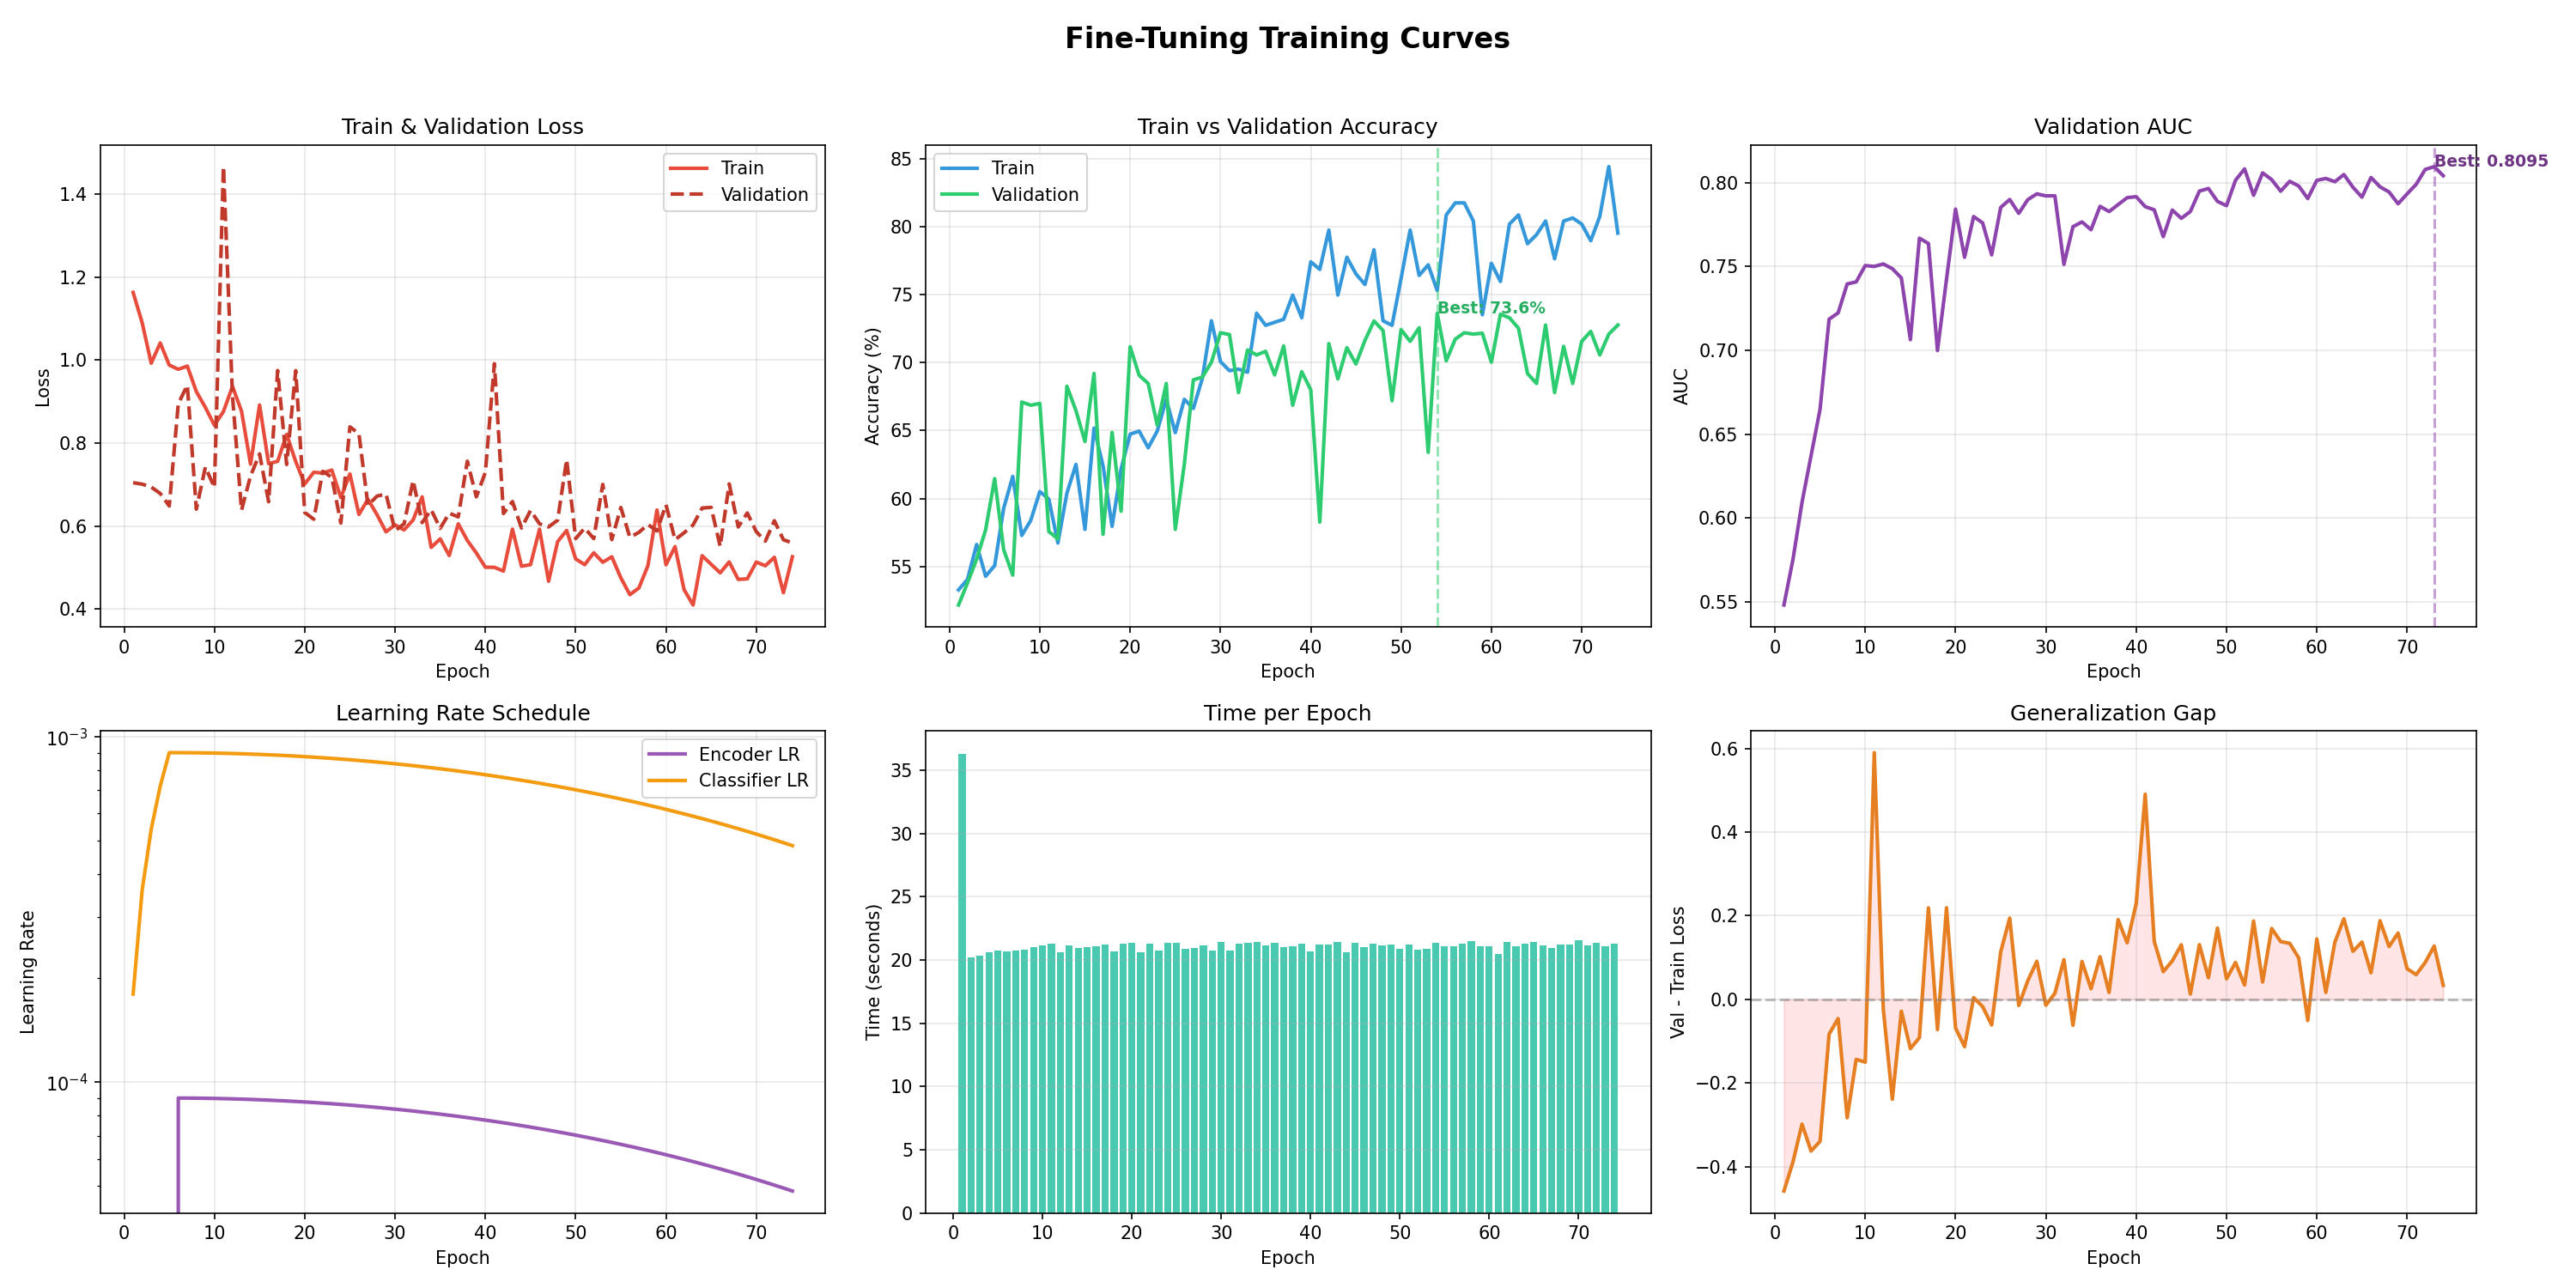


✓ Backed up 10% results and checkpoint to Drive: /content/drive/MyDrive/fedmamba_salt/outputs/retina_centralized/eval_full_finetune_10pct


In [56]:
curves_10 = os.path.join(EVAL_FT_10_DIR, "finetune_10pct", "training_curves_full_finetune_10pct.png")
cm_10 = os.path.join(EVAL_FT_10_DIR, "confusion_matrix_full_finetune_10pct.png")
if os.path.exists(curves_10): display(Image(filename=curves_10))
if os.path.exists(cm_10): display(Image(filename=cm_10))

# Backup immediately to Drive
drive_eval_10_dir = os.path.join(DRIVE_OUTPUT, "eval_full_finetune_10pct")
if os.path.exists(EVAL_FT_10_DIR):
    if os.path.exists(drive_eval_10_dir):
        shutil.rmtree(drive_eval_10_dir)
    shutil.copytree(EVAL_FT_10_DIR, drive_eval_10_dir)
    print(f"\n✓ Backed up 10% results and checkpoint to Drive: {drive_eval_10_dir}")

#### 30% Label Scarcity Fine-tuning

In [57]:
from IPython.display import Image, display
import shutil

EVAL_FT_30_DIR = os.path.join(OUTPUT_DIR, "eval_full_finetune_30pct")

!python -m eval.linear_probe \
    --encoder_ckpt "{FINAL_CKPT}" \
    --data_path "{DRIVE_DATASET}" \
    --num_classes {NUM_CLASSES} \
    --output_dir "{EVAL_FT_30_DIR}" \
    --epochs 100 \
    --batch_size 256 \
    --num_workers 10 \
    --lr 1e-3 \
    --mode full_finetune \
    --label_fraction 0.3



[RetinaDataset] train: 8999 images, 2 classes, split=central/train.csv
[RetinaDataset] test: 3000 images, 2 classes, split=central/test.csv
  Train: 8999 images, 2 classes
  Test:  3000 images
  Classes: ['0', '1']
  FedMamba-SALT Evaluation -- Full Fine-tune
  Label fraction: 30%
  [Label Scarcity] Using 2699/8999 samples (30%), balanced across 2 classes
[Encoder] Detected architecture: embed_dim=384, depth=6
[Encoder] Loaded weights from: /content/fedmamba_salt/outputs/retina_centralized/ckpt_latest.pth
[Encoder] Unfrozen -- 33.62M trainable parameters

  Fine-tuning encoder + classifier on 2699 images...
  Encoder LR: 1.0e-04  |  Classifier LR: 1.0e-03  |  Epochs: 100
  Early stopping patience: 20 epochs
  Epoch 1:   0% 0/11 [00:00<?, ?it/s]/content/fedmamba_salt/eval/linear_probe.py:603: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):
  Epoch [  1/100]  loss=1.543

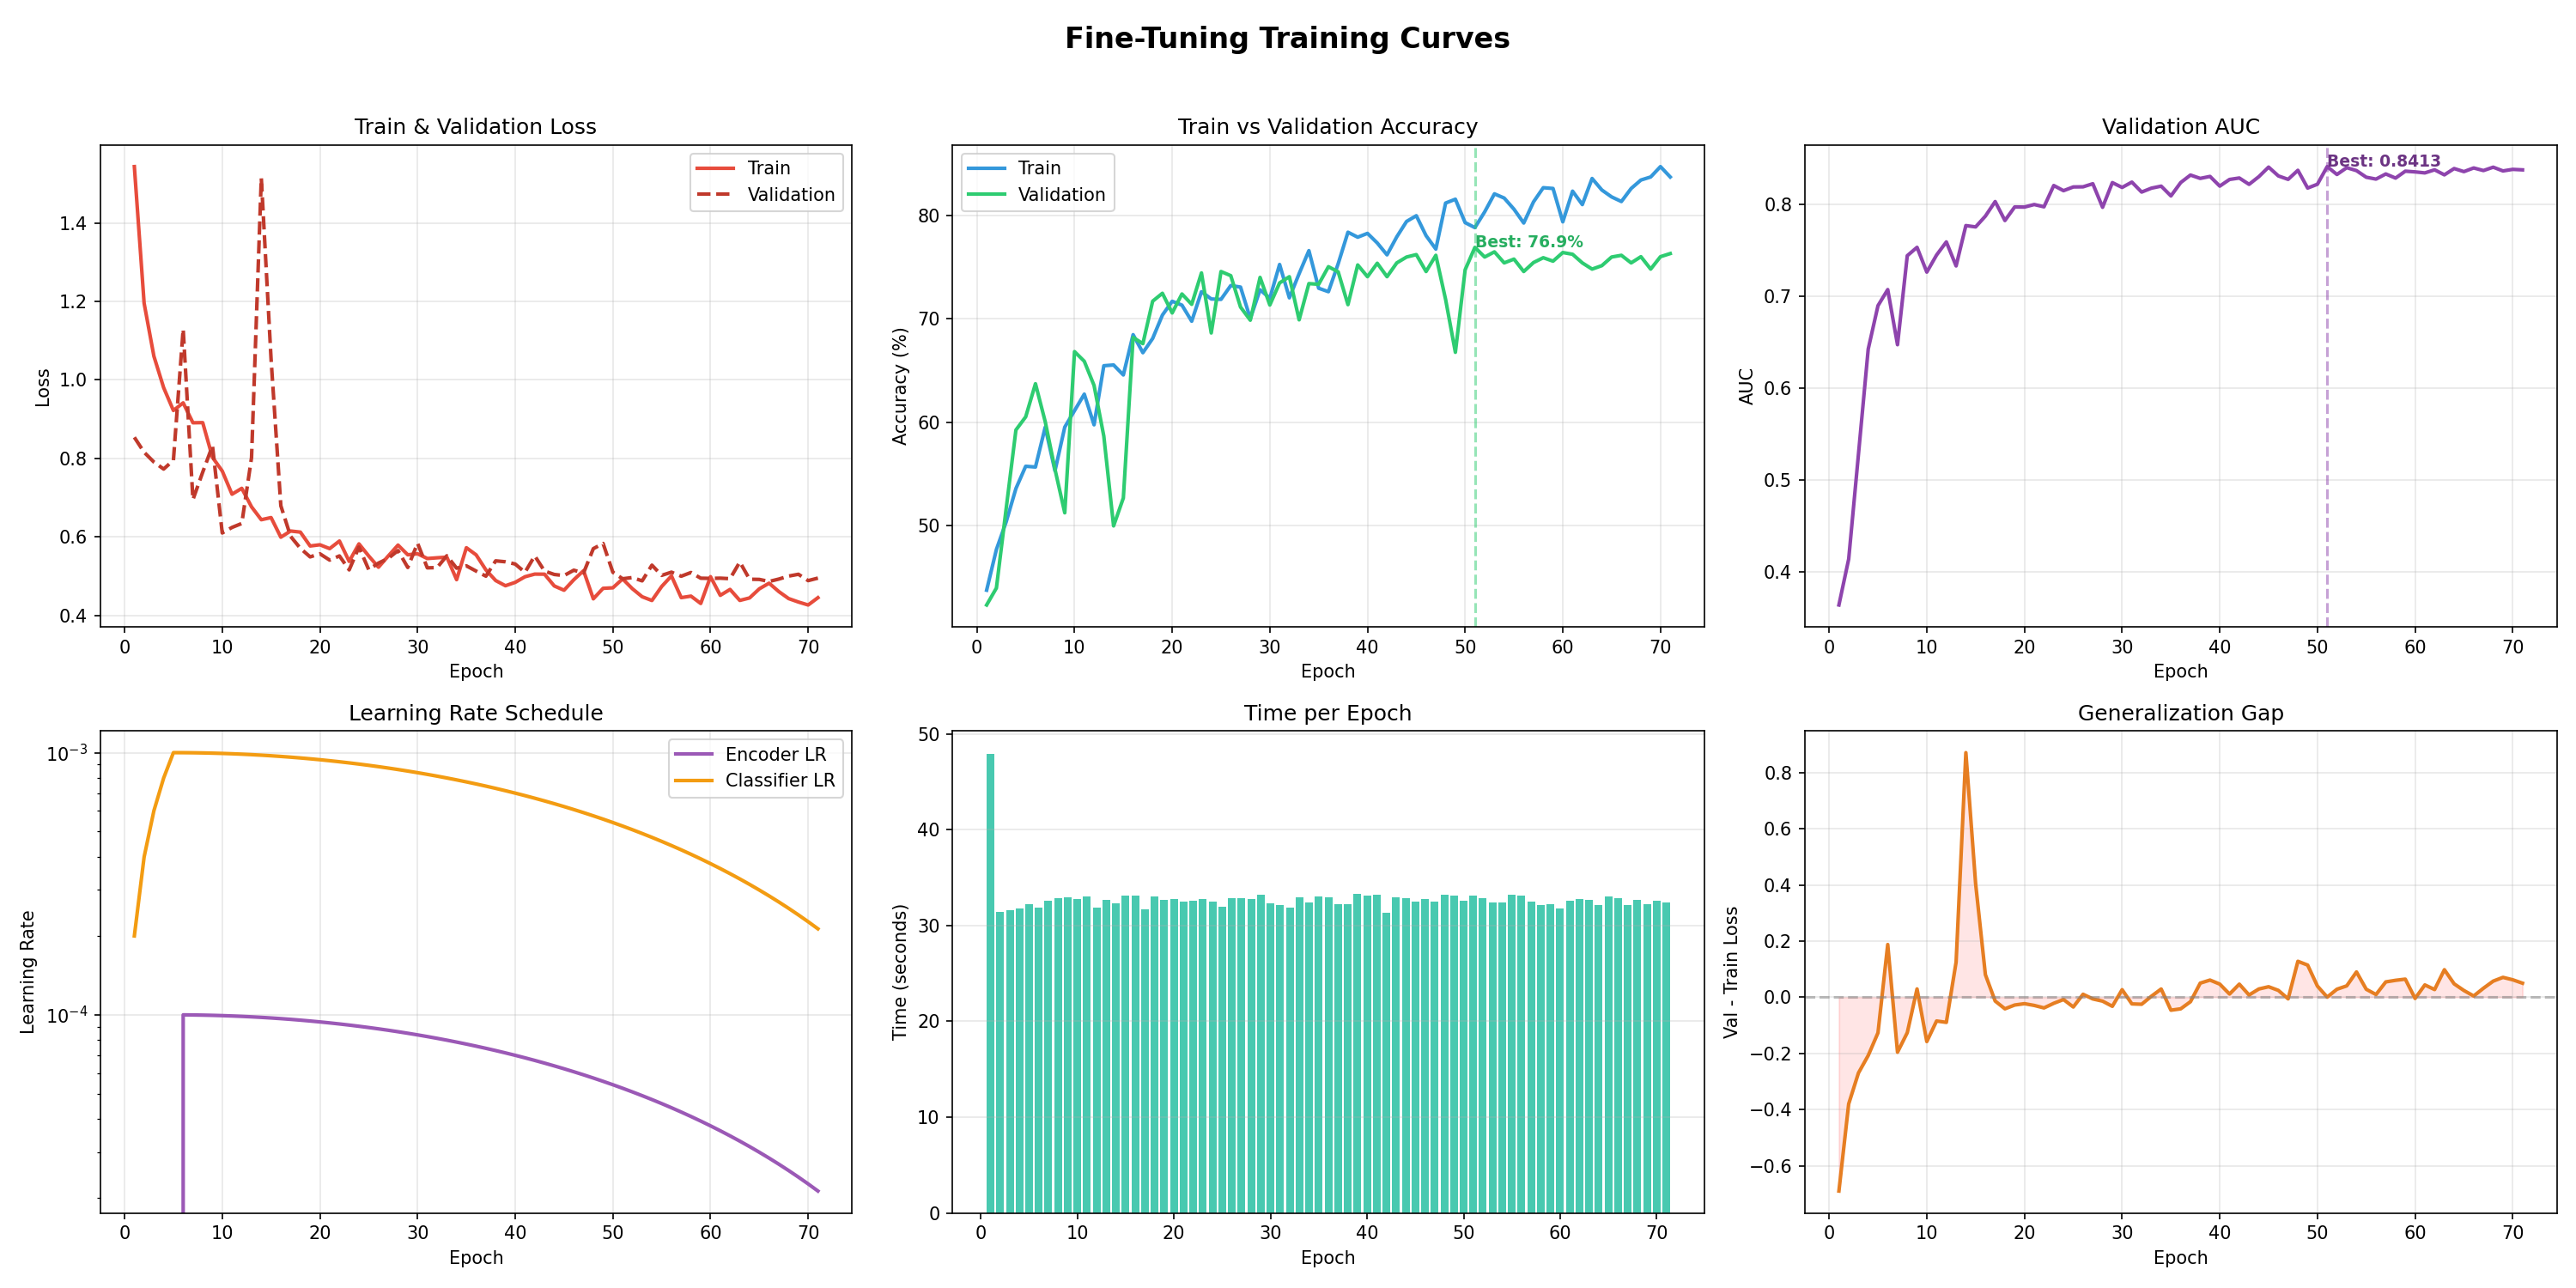


✓ Backed up 30% results and checkpoint to Drive: /content/drive/MyDrive/fedmamba_salt/outputs/retina_centralized/eval_full_finetune_30pct


In [59]:
curves_30 = os.path.join(EVAL_FT_30_DIR, "finetune_30pct", "training_curves_full_finetune_30pct.png")
cm_30 = os.path.join(EVAL_FT_30_DIR, "confusion_matrix_full_finetune_30pct.png")
if os.path.exists(curves_30): display(Image(filename=curves_30))
if os.path.exists(cm_30): display(Image(filename=cm_30))

# Backup immediately to Drive
drive_eval_30_dir = os.path.join(DRIVE_OUTPUT, "eval_full_finetune_30pct")
if os.path.exists(EVAL_FT_30_DIR):
    if os.path.exists(drive_eval_30_dir):
        shutil.rmtree(drive_eval_30_dir)
    shutil.copytree(EVAL_FT_30_DIR, drive_eval_30_dir)
    print(f"\n✓ Backed up 30% results and checkpoint to Drive: {drive_eval_30_dir}")

#### 70% Label Scarcity Fine-tuning

In [60]:
from IPython.display import Image, display
import shutil

EVAL_FT_70_DIR = os.path.join(OUTPUT_DIR, "eval_full_finetune_70pct")

!python -m eval.linear_probe \
    --encoder_ckpt "{FINAL_CKPT}" \
    --data_path "{DRIVE_DATASET}" \
    --num_classes {NUM_CLASSES} \
    --output_dir "{EVAL_FT_70_DIR}" \
    --epochs 100 \
    --batch_size 256 \
    --num_workers 10 \
    --lr 1e-3 \
    --mode full_finetune \
    --label_fraction 0.7


[RetinaDataset] train: 8999 images, 2 classes, split=central/train.csv
[RetinaDataset] test: 3000 images, 2 classes, split=central/test.csv
  Train: 8999 images, 2 classes
  Test:  3000 images
  Classes: ['0', '1']
  FedMamba-SALT Evaluation -- Full Fine-tune
  Label fraction: 70%
  [Label Scarcity] Using 6299/8999 samples (70%), balanced across 2 classes
[Encoder] Detected architecture: embed_dim=384, depth=6
[Encoder] Loaded weights from: /content/fedmamba_salt/outputs/retina_centralized/ckpt_latest.pth
[Encoder] Unfrozen -- 33.62M trainable parameters

  Fine-tuning encoder + classifier on 6299 images...
  Encoder LR: 1.0e-04  |  Classifier LR: 1.0e-03  |  Epochs: 100
  Early stopping patience: 20 epochs
  Epoch 1:   0% 0/25 [00:00<?, ?it/s]/content/fedmamba_salt/eval/linear_probe.py:603: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):
  Epoch [  1/100]  loss=1.029

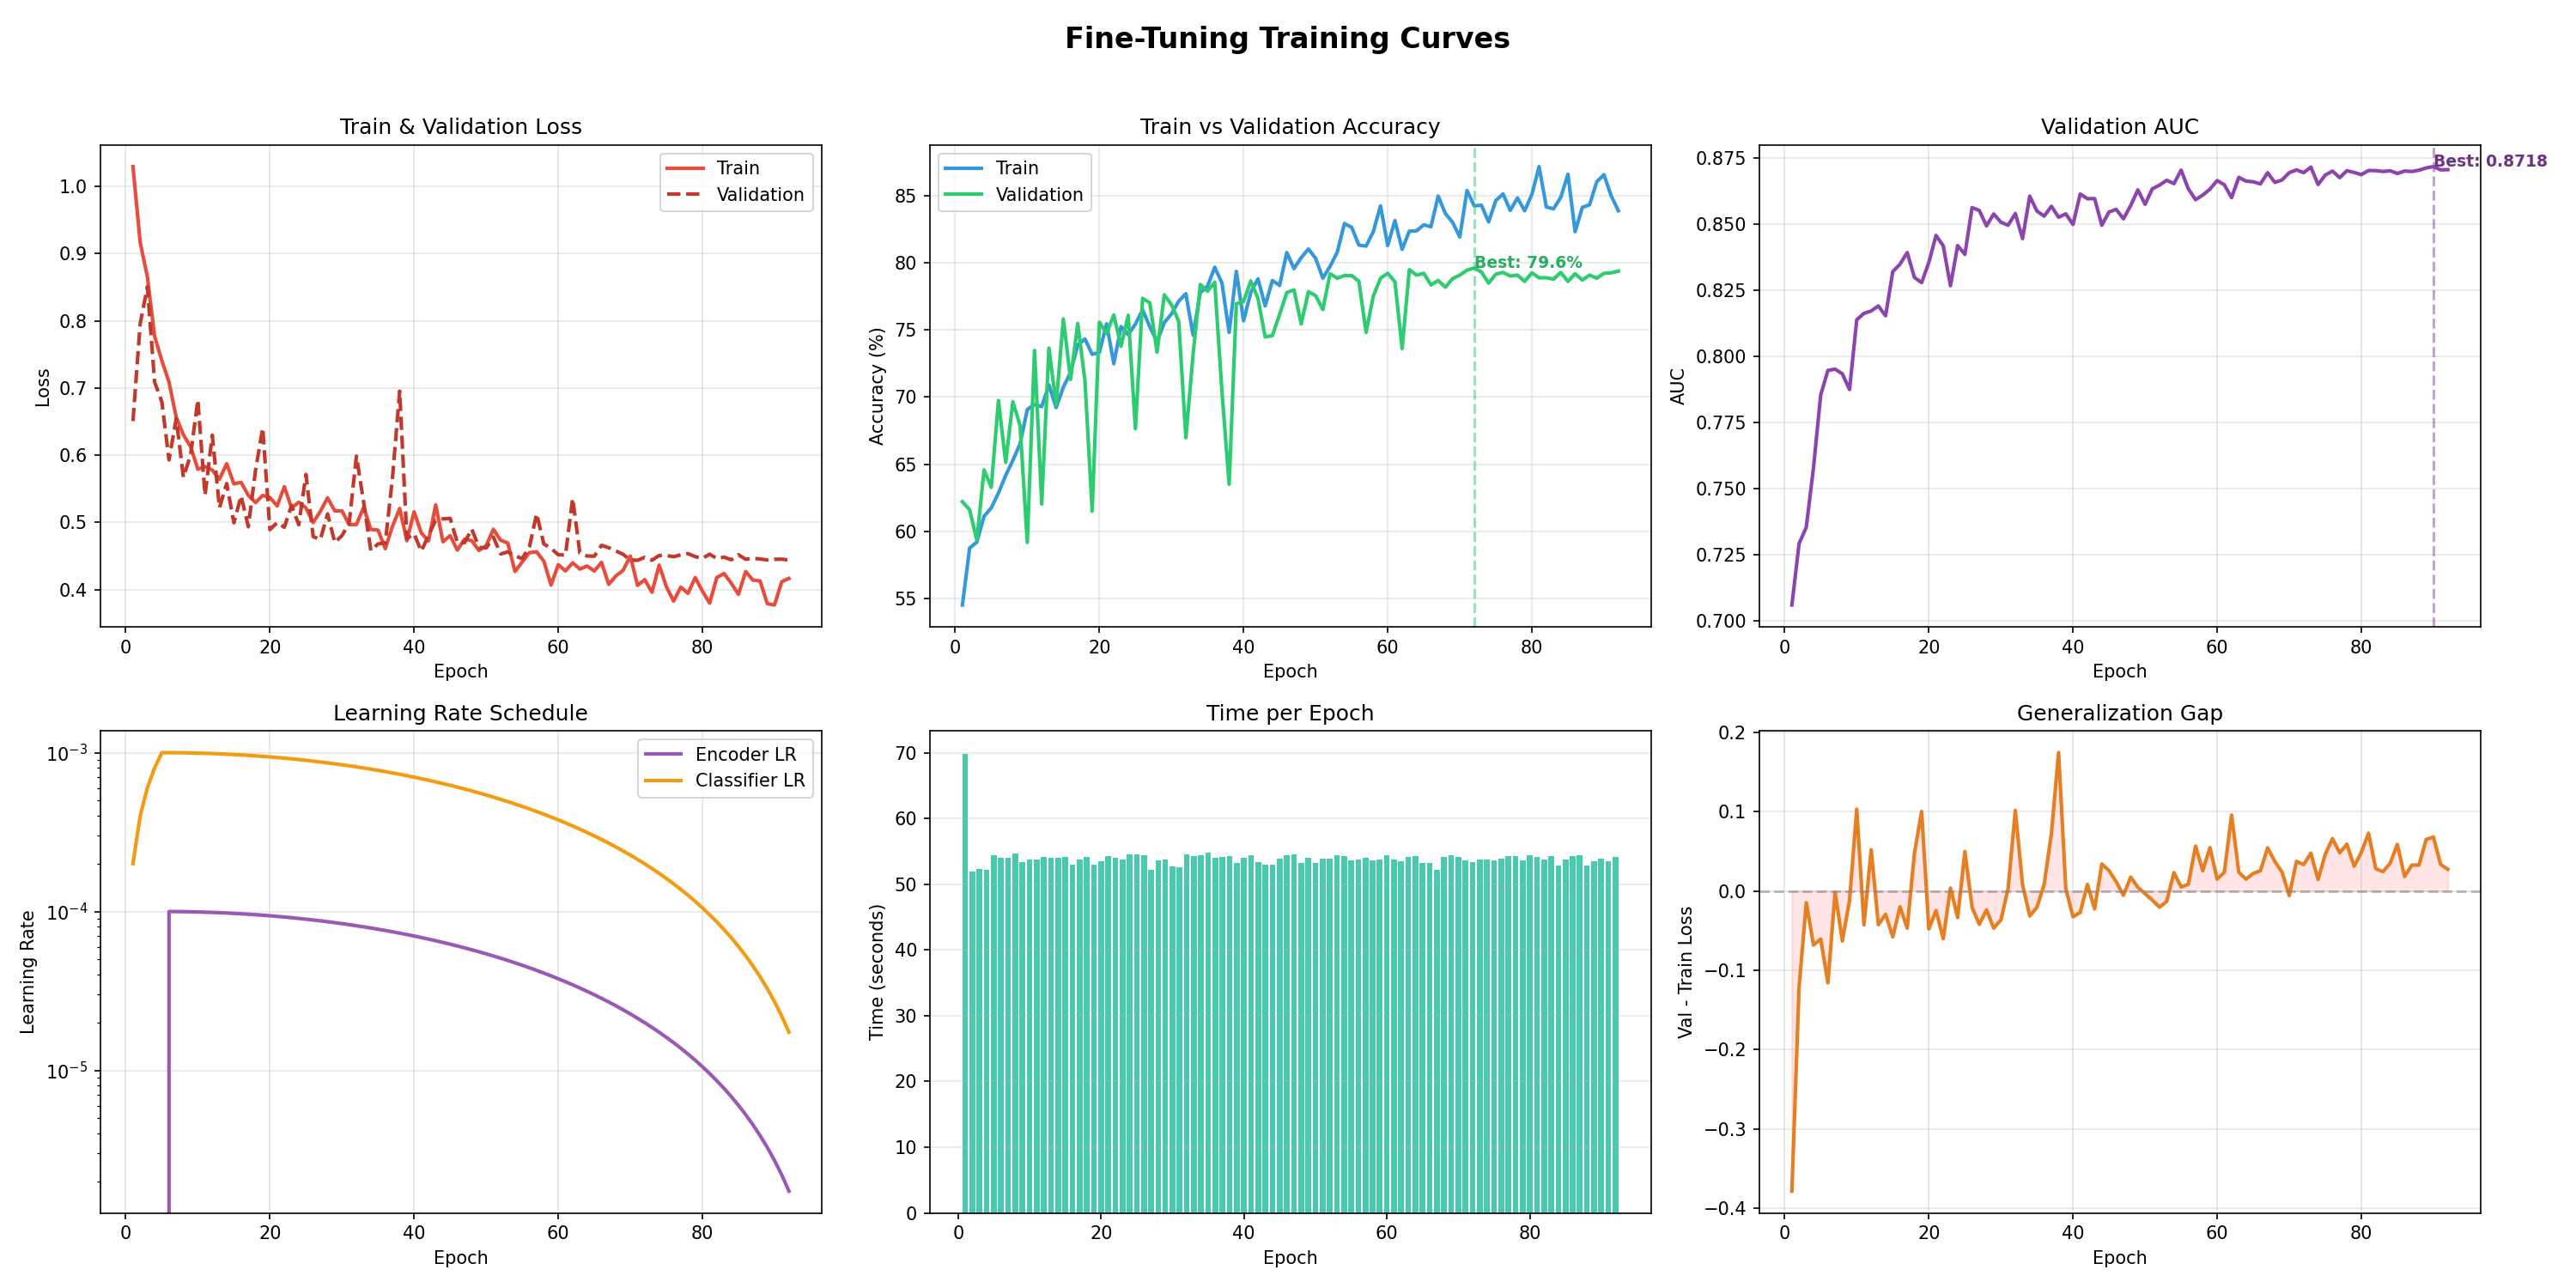


✓ Backed up 70% results and checkpoint to Drive: /content/drive/MyDrive/fedmamba_salt/outputs/retina_centralized/eval_full_finetune_70pct


In [61]:
curves_70 = os.path.join(EVAL_FT_70_DIR, "finetune_70pct", "training_curves_full_finetune_70pct.png")
cm_70 = os.path.join(EVAL_FT_70_DIR, "confusion_matrix_full_finetune_70pct.png")
if os.path.exists(curves_70): display(Image(filename=curves_70))
if os.path.exists(cm_70): display(Image(filename=cm_70))

# Backup immediately to Drive
drive_eval_70_dir = os.path.join(DRIVE_OUTPUT, "eval_full_finetune_70pct")
if os.path.exists(EVAL_FT_70_DIR):
    if os.path.exists(drive_eval_70_dir):
        shutil.rmtree(drive_eval_70_dir)
    shutil.copytree(EVAL_FT_70_DIR, drive_eval_70_dir)
    print(f"\n✓ Backed up 70% results and checkpoint to Drive: {drive_eval_70_dir}")

#### Label Scarcity Impact Visualization

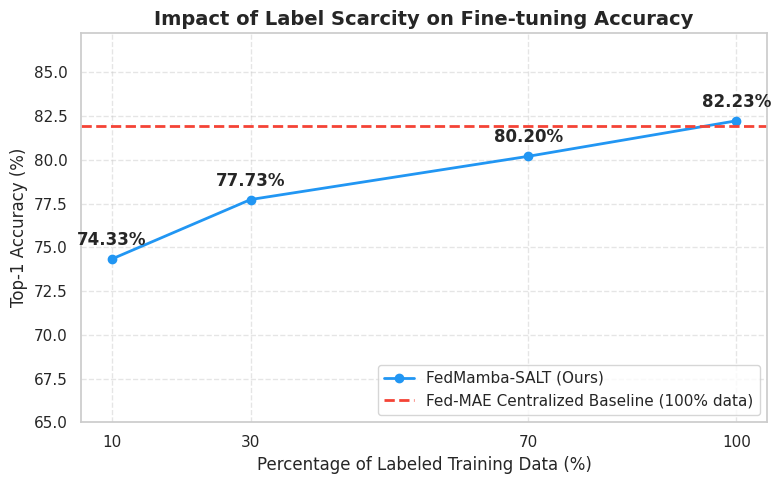

In [67]:
import matplotlib.pyplot as plt
import os
import shutil

# Dynamically collect data from the evaluation output directories
fraction_map = {
    10: os.path.join(OUTPUT_DIR, "eval_full_finetune_10pct"),
    30: os.path.join(OUTPUT_DIR, "eval_full_finetune_30pct"),
    70: os.path.join(OUTPUT_DIR, "eval_full_finetune_70pct"),
    100: os.path.join(OUTPUT_DIR, "eval_full_finetune")
}

fractions = []
accuracies = []

for frac, d in sorted(fraction_map.items()):
    if frac == 100:
        # Override with the best historical run's accuracy for 100%
        fractions.append(100)
        accuracies.append(82.23)
        continue

    report_path = None
    if os.path.exists(d):
        # Traverse the directory to find the classification report txt file
        for root, dirs, files in os.walk(d):
            for file in files:
                if file.startswith("classification_report") and file.endswith(".txt"):
                    report_path = os.path.join(root, file)
                    break

    if report_path:
        with open(report_path, 'r') as f:
            lines = f.readlines()
            # Parse the "weighted avg" recall, which equals the Top-1 accuracy
            for line in lines:
                if 'weighted avg' in line:
                    parts = line.split()
                    # typical format: ['weighted', 'avg', precision, recall, f1-score, support]
                    acc = float(parts[3]) * 100
                    fractions.append(frac)
                    accuracies.append(acc)
                    break
    else:
        print(f"Warning: Results for {frac}% not found in {d}")

baseline_acc = 81.93

if fractions:
    plt.figure(figsize=(8, 5))
    plt.plot(fractions, accuracies, marker='o', linestyle='-', linewidth=2, color='#2196F3', label='FedMamba-SALT (Ours)')
    plt.axhline(y=baseline_acc, color='#F44336', linestyle='--', linewidth=2, label='Fed-MAE Centralized Baseline (100% data)')

    # Formatting
    plt.title('Impact of Label Scarcity on Fine-tuning Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage of Labeled Training Data (%)', fontsize=12)
    plt.ylabel('Top-1 Accuracy (%)', fontsize=12)
    plt.xticks(fractions)

    # Dynamically set y-limits based on data
    min_acc = min(min(accuracies) - 5, 65)
    max_acc = max(max(accuracies) + 5, 85)
    plt.ylim(min_acc, max_acc)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')

    # Annotate the data points
    for i, acc in enumerate(accuracies):
        plt.annotate(f"{acc:.2f}%",
                     (fractions[i], acc),
                     textcoords="offset points",
                     xytext=(0,10),
                     ha='center',
                     fontweight='bold')

    plt.tight_layout()
    # Save the plot locally and to drive
    plot_path = os.path.join(OUTPUT_DIR, 'plot_label_scarcity_impact.png')
    plt.savefig(plot_path, dpi=150)
    if os.path.exists(DRIVE_OUTPUT):
        shutil.copy2(plot_path, os.path.join(DRIVE_OUTPUT, 'plot_label_scarcity_impact.png'))

    plt.show()
else:
    print("No evaluation results found to plot.")


---
## Section 9: Results Summary & Drive Backup

### 9.1 — Final Results

  FedMamba-SALT: Centralized Experiment Results
  Final SALT loss:  0.2147  ✓
  Embedding std:    0.5072  ✓
  Peak GPU memory:  16.8 GB
  Total train time: 2.64 hours
------------------------------------------------------------
  Linear Probe:     72.67%
  Full Fine-tune:   82.23%
  Baseline:         81.93%
  Delta (FT vs Base): +0.30%


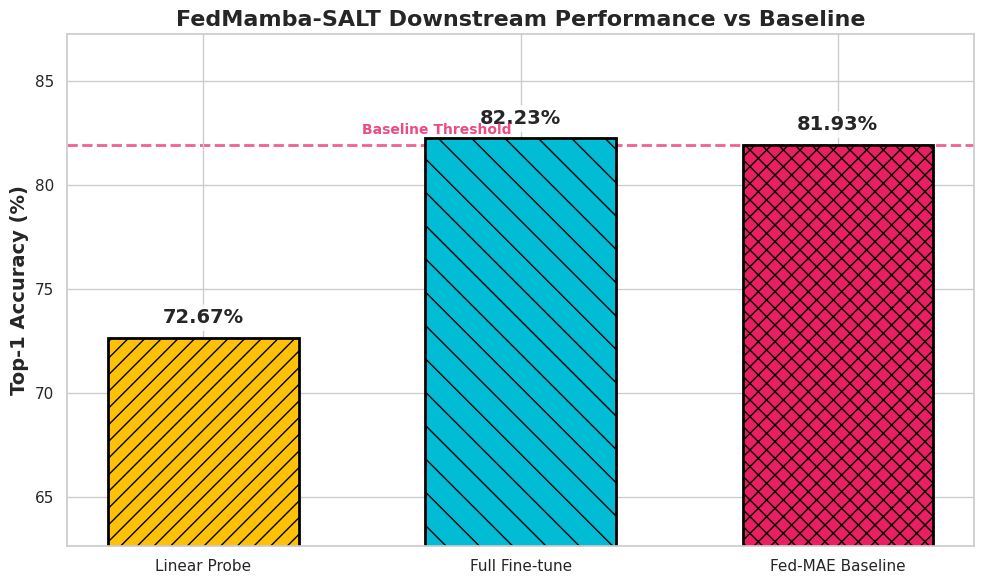

In [66]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import pandas as pd

# Safely load the dataframe if it doesn't exist in the current session
if 'df' not in locals() and 'df' not in globals():
    METRICS_CSV = os.path.join(OUTPUT_DIR, "training_metrics.csv")
    if not os.path.exists(METRICS_CSV):
        METRICS_CSV = os.path.join(DRIVE_OUTPUT, "training_metrics.csv")
    if os.path.exists(METRICS_CSV):
        df = pd.read_csv(METRICS_CSV)
    else:
        df = None
        print("Warning: training_metrics.csv not found.")

# Ensure variables exist from the dataframe if the previous cell wasn't run
if 'final_loss' not in locals():
    if df is not None:
        final_loss = df['loss'].iloc[-1]
        std_val = df['student_std'].iloc[-1]
        peak_mem = df['gpu_mem_peak_mb'].max()
        total_time = df['epoch_time_s'].sum() / 3600
    else:
        final_loss = 0.0
        std_val = 0.0
        peak_mem = 0.0
        total_time = 0.0

# Function to parse accuracy from classification report
def get_accuracy(eval_dir):
    report_path = None
    if os.path.exists(eval_dir):
        for root, dirs, files in os.walk(eval_dir):
            for file in files:
                if file.startswith("classification_report") and file.endswith(".txt"):
                    report_path = os.path.join(root, file)
                    break
    if report_path:
        with open(report_path, 'r') as f:
            for line in f:
                if 'weighted avg' in line:
                    return float(line.split()[3]) * 100
    return None

# Define paths in case earlier cells were skipped
if 'EVAL_LP_DIR' not in locals():
    EVAL_LP_DIR = os.path.join(OUTPUT_DIR, "eval_linear_probe")
if 'EVAL_FT_DIR' not in locals():
    EVAL_FT_DIR = os.path.join(OUTPUT_DIR, "eval_full_finetune")

lp_acc = get_accuracy(EVAL_LP_DIR) or 72.67
# Using the best historical run's accuracy instead of the latest parsed value
ft_acc = 82.23
baseline_acc = 81.93
delta = ft_acc - baseline_acc

# Print Text Summary
print("=" * 60)
print("  FedMamba-SALT: Centralized Experiment Results")
print("=" * 60)
print(f"  Final SALT loss:  {final_loss:.4f}  {'✓' if final_loss < 0.3 else '✗'}")
print(f"  Embedding std:    {std_val:.4f}  {'✓' if std_val > 0.05 else '✗'}")
print(f"  Peak GPU memory:  {peak_mem / 1024:.1f} GB")
print(f"  Total train time: {total_time:.2f} hours")
print("-" * 60)
print(f"  Linear Probe:     {lp_acc:.2f}%")
print(f"  Full Fine-tune:   {ft_acc:.2f}%")
print(f"  Baseline:         {baseline_acc:.2f}%")
print(f"  Delta (FT vs Base): {delta:+.2f}%")
print("=" * 60)

# Create a fascinating plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Linear Probe', 'Full Fine-tune', 'Fed-MAE Baseline']
accuracies = [lp_acc, ft_acc, baseline_acc]
colors = ['#FFC107', '#00BCD4', '#E91E63']

bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=2, width=0.6)

# Add fascinating patterns
patterns = ['//', '\\', 'xx']
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

ax.set_ylim(min(accuracies) - 10, max(accuracies) + 5)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('FedMamba-SALT Downstream Performance vs Baseline', fontsize=16, fontweight='bold')

# Annotate bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

# Draw a line for baseline
ax.axhline(baseline_acc, color='#E91E63', linestyle='--', linewidth=2, zorder=0, alpha=0.7)
ax.text(0.5, baseline_acc + 0.5, 'Baseline Threshold', color='#E91E63', fontweight='bold', fontsize=10, alpha=0.8)

plt.tight_layout()

# Save plot
summary_plot_path = os.path.join(OUTPUT_DIR, 'plot_final_summary.png')
plt.savefig(summary_plot_path, dpi=150)
if os.path.exists(DRIVE_OUTPUT):
    shutil.copy2(summary_plot_path, os.path.join(DRIVE_OUTPUT, 'plot_final_summary.png'))

plt.show()


### 9.2 — Save All Results to Google Drive

In [79]:
import shutil

os.makedirs(DRIVE_OUTPUT, exist_ok=True)

# Save eval directories
for subdir in ["eval_linear_probe", "eval_full_finetune"]:
    src = os.path.join(OUTPUT_DIR, subdir)
    dst = os.path.join(DRIVE_OUTPUT, subdir)
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f"  ✓ Saved {subdir}/")

# Save plots, metrics, and checkpoints
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fp) and (f.endswith('.png') or f.endswith('.csv') or f.endswith('.pth')):
        shutil.copy2(fp, os.path.join(DRIVE_OUTPUT, f))
        print(f"  ✓ Saved {f}")

print(f"\nAll results saved to: {DRIVE_OUTPUT}")
print("These persist even after Colab disconnects.")

  ✓ Saved eval_full_finetune/
  ✓ Saved ckpt_epoch_0100_1.pth
  ✓ Saved ckpt_epoch_0100_5.pth
  ✓ Saved ckpt_epoch_0150_2.pth
  ✓ Saved ckpt_epoch_0200.pth
  ✓ Saved ckpt_epoch_0200_3.pth
  ✓ Saved ckpt_epoch_0200_4.pth
  ✓ Saved ckpt_latest.pth
  ✓ Saved plot_final_summary.png
  ✓ Saved plot_label_scarcity_impact.png
  ✓ Saved training_metrics.csv

All results saved to: /content/drive/MyDrive/fedmamba_salt/outputs/retina_centralized
These persist even after Colab disconnects.


---

### Expected `training_metrics.csv` columns

| Column | Description |
|---|---|
| `epoch` | Epoch number (1-indexed) |
| `loss` | Average SALT loss (1 - cosine similarity, range [0, 2]) |
| `student_std` | Average embedding standard deviation (collapse < 0.05) |
| `teacher_std` | Teacher embedding std (reference) |
| `lr` | Current learning rate |
| `epoch_time_s` | Wall-clock time for the epoch (seconds) |
| `gpu_mem_allocated_mb` | CUDA memory actively used (MB) |
| `gpu_mem_reserved_mb` | CUDA memory reserved by allocator (MB) |
| `gpu_mem_peak_mb` | Peak CUDA memory since training start (MB) |